# CPE 166 — HDL + Photonics Project
## FPGA-Based FSM Timing Controller for a Photonic Pulse Monitor

**Connection to GS Phase Retrieval**: this FPGA controller sequences the dispersive fiber
measurement used in TD-GS. The FSM gates the ADC capture window, triggers the reference
arm, and raises `DIVERSITY_RDY` when $|D| \geq 5000$ ps² of dispersion has been applied.

| Deliverable | Status |
|---|---|
| 1. Block diagram | §1 |
| 2. Verilog module | §2 |
| 3. VHDL comparison | §3 |
| 4. FSM state diagram + table | §4 |
| 5. Python testbench simulation | §5 |
| 6. PLD/FPGA implementation note | §6 |


## §1 Block Diagram — RTL Architecture

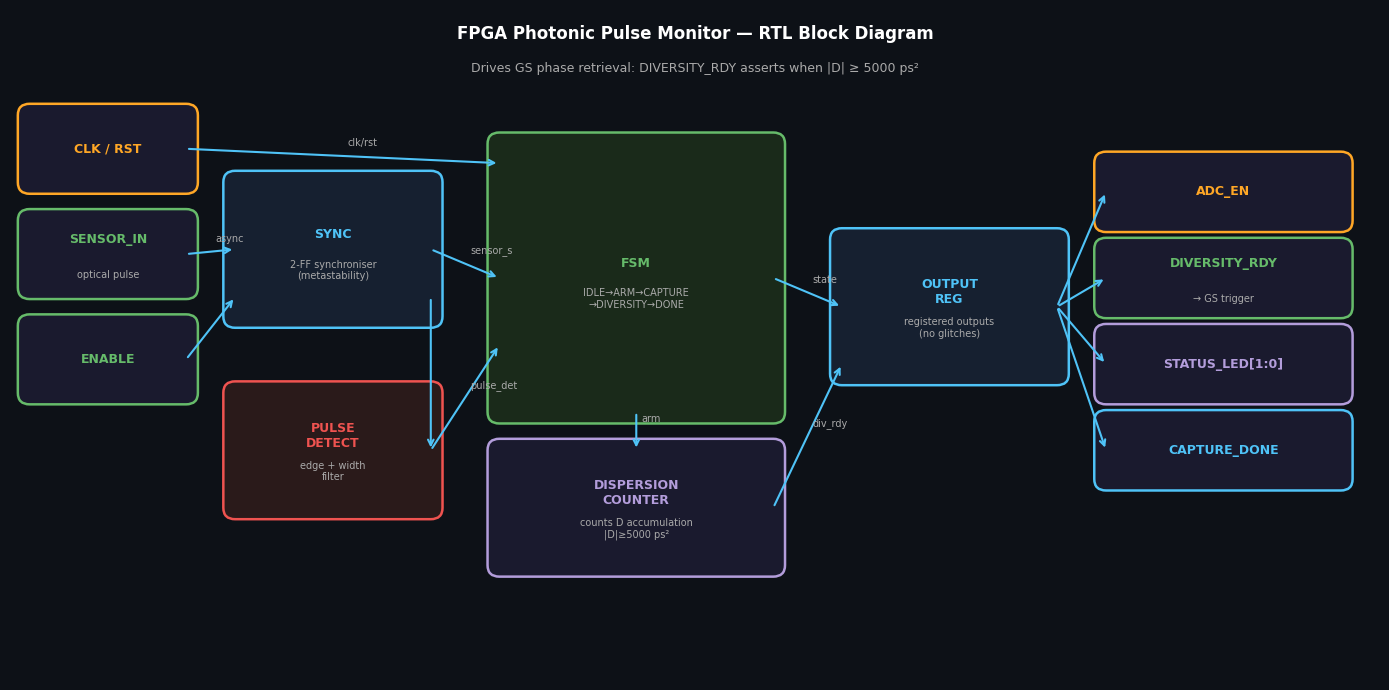

Block diagram rendered.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 14); ax.set_ylim(0, 7); ax.axis('off')

def box(ax, x, y, w, h, label, sublabel='', color='#1e2d40', tcolor='#4fc3f7'):
    rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12',
                           facecolor=color, edgecolor=tcolor, lw=1.8)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2+(0.15 if sublabel else 0), label,
            ha='center', va='center', color=tcolor, fontsize=9, fontweight='bold')
    if sublabel:
        ax.text(x+w/2, y+h/2-0.22, sublabel, ha='center', va='center',
                color='#aaa', fontsize=7)

def arrow(ax, x0, y0, x1, y1, label='', col='#4fc3f7'):
    ax.annotate('', (x1,y1), (x0,y0),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.5))
    if label:
        mx, my = (x0+x1)/2, (y0+y1)/2
        ax.text(mx+0.05, my+0.1, label, color='#aaa', fontsize=7)

# Input signals
box(ax, 0.2, 5.2, 1.6, 0.7, 'CLK / RST', '', '#1a1a2e', '#ffa726')
box(ax, 0.2, 4.1, 1.6, 0.7, 'SENSOR_IN', 'optical pulse', '#1a1a2e', '#66bb6a')
box(ax, 0.2, 3.0, 1.6, 0.7, 'ENABLE',    '', '#1a1a2e', '#66bb6a')

# Synchroniser (metastability filter)
box(ax, 2.3, 3.8, 2.0, 1.4, 'SYNC', '2-FF synchroniser\n(metastability)', '#162030')
arrow(ax, 1.8, 4.45, 2.3, 4.5, 'async')
arrow(ax, 1.8, 3.35, 2.3, 4.0)

# FSM
box(ax, 5.0, 2.8, 2.8, 2.8, 'FSM', 'IDLE→ARM→CAPTURE\n→DIVERSITY→DONE', '#1a2a1a', '#66bb6a')
arrow(ax, 4.3, 4.5, 5.0, 4.2, 'sensor_s')
arrow(ax, 1.8, 5.55, 5.0, 5.4, 'clk/rst')

# Pulse detector
box(ax, 2.3, 1.8, 2.0, 1.2, 'PULSE\nDETECT', 'edge + width\nfilter', '#2a1a1a', '#ef5350')
arrow(ax, 4.3, 4.0, 4.3, 2.4, '')
arrow(ax, 4.3, 2.4, 5.0, 3.5, 'pulse_det')

# Counter
box(ax, 5.0, 1.2, 2.8, 1.2, 'DISPERSION\nCOUNTER', 'counts D accumulation\n|D|≥5000 ps²', '#1a1a2e', '#b39ddb')
arrow(ax, 6.4, 2.8, 6.4, 2.4, 'arm')

# Output mux
box(ax, 8.5, 3.2, 2.2, 1.4, 'OUTPUT\nREG', 'registered outputs\n(no glitches)', '#162030')
arrow(ax, 7.8, 4.2, 8.5, 3.9, 'state')
arrow(ax, 7.8, 1.8, 8.5, 3.3, 'div_rdy')

# Outputs
box(ax, 11.2, 4.8, 2.4, 0.6, 'ADC_EN',      '', '#1a1a2e', '#ffa726')
box(ax, 11.2, 3.9, 2.4, 0.6, 'DIVERSITY_RDY','→ GS trigger', '#1a1a2e', '#66bb6a')
box(ax, 11.2, 3.0, 2.4, 0.6, 'STATUS_LED[1:0]','', '#1a1a2e', '#b39ddb')
box(ax, 11.2, 2.1, 2.4, 0.6, 'CAPTURE_DONE','', '#1a1a2e', '#4fc3f7')
arrow(ax, 10.7, 3.9, 11.2, 5.1, '')
arrow(ax, 10.7, 3.9, 11.2, 4.2, '')
arrow(ax, 10.7, 3.9, 11.2, 3.3, '')
arrow(ax, 10.7, 3.9, 11.2, 2.4, '')

ax.text(7, 6.7, 'FPGA Photonic Pulse Monitor — RTL Block Diagram',
        ha='center', color='white', fontsize=12, fontweight='bold')
ax.text(7, 6.35, 'Drives GS phase retrieval: DIVERSITY_RDY asserts when |D| ≥ 5000 ps²',
        ha='center', color='#aaa', fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/block_diagram.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Block diagram rendered.")


## §2 Verilog Module — RTL (Synthesisable)

Five states: `IDLE → ARM → CAPTURE → DIVERSITY → DONE`

Blocking vs non-blocking rule (CPE 166 Unit 3):
- **Sequential logic** (`always @(posedge clk)`): use `<=` (non-blocking)
- **Combinational logic** (`always @(*)`): use `=` (blocking)


In [2]:
VERILOG_MODULE = r"""
// ============================================================
// photon_pulse_monitor.v
// FPGA FSM controller for TD-GS photonic pulse measurement
// CPE 166 Final Project — Colin Casey
// Inputs : clk, rst_n, sensor_in, enable
// Outputs: adc_en, diversity_rdy, capture_done, status_led
// ============================================================
module photon_pulse_monitor #(
    parameter CLK_FREQ   = 100_000_000,   // 100 MHz
    parameter DIV_TARGET = 5000           // dispersion counts (proxy for |D|>=5000 ps^2)
)(
    input  wire        clk,
    input  wire        rst_n,       // active-low reset
    input  wire        sensor_in,   // async optical sensor (active HIGH = pulse detected)
    input  wire        enable,
    output reg         adc_en,
    output reg         diversity_rdy,
    output reg         capture_done,
    output reg  [1:0]  status_led   // 00=idle 01=arm 10=capture 11=done
);

// ── State encoding (Gray code reduces glitch risk) ──────────────────────────
localparam [2:0]
    IDLE       = 3'b000,
    ARM        = 3'b001,
    CAPTURE    = 3'b011,
    DIVERSITY  = 3'b010,
    DONE       = 3'b110;

reg [2:0] state, next_state;

// ── 2-FF synchroniser (metastability filter) ─────────────────────────────────
reg sensor_ff1, sensor_ff2;
always @(posedge clk or negedge rst_n) begin
    if (!rst_n) begin
        sensor_ff1 <= 1'b0;
        sensor_ff2 <= 1'b0;
    end else begin
        sensor_ff1 <= sensor_in;   // stage 1: resolve metastability
        sensor_ff2 <= sensor_ff1;  // stage 2: stable output
    end
end
wire sensor_s = sensor_ff2;

// ── Dispersion counter ────────────────────────────────────────────────────────
reg [15:0] div_count;
wire       div_reached = (div_count >= DIV_TARGET);

// ── Sequential: state register + counter ─────────────────────────────────────
always @(posedge clk or negedge rst_n) begin
    if (!rst_n) begin
        state     <= IDLE;
        div_count <= 16'd0;
    end else begin
        state <= next_state;
        if (state == DIVERSITY && !div_reached)
            div_count <= div_count + 1'b1;
        else if (state == IDLE)
            div_count <= 16'd0;
    end
end

// ── Combinational: next-state logic ──────────────────────────────────────────
always @(*) begin
    next_state = state;
    case (state)
        IDLE:      if (enable)              next_state = ARM;
        ARM:       if (sensor_s)            next_state = CAPTURE;
        CAPTURE:   if (!sensor_s)           next_state = DIVERSITY;
        DIVERSITY: if (div_reached)         next_state = DONE;
        DONE:      if (!enable)             next_state = IDLE;
        default:                            next_state = IDLE;
    endcase
end

// ── Registered outputs (Moore machine, no glitches) ──────────────────────────
always @(posedge clk or negedge rst_n) begin
    if (!rst_n) begin
        adc_en        <= 1'b0;
        diversity_rdy <= 1'b0;
        capture_done  <= 1'b0;
        status_led    <= 2'b00;
    end else begin
        adc_en        <= (next_state == CAPTURE);
        diversity_rdy <= (next_state == DONE);
        capture_done  <= (next_state == DONE);
        status_led    <= next_state[1:0];
    end
end

endmodule
"""

print(VERILOG_MODULE)



// ============================================================
// photon_pulse_monitor.v
// FPGA FSM controller for TD-GS photonic pulse measurement
// CPE 166 Final Project — Colin Casey
// Inputs : clk, rst_n, sensor_in, enable
// Outputs: adc_en, diversity_rdy, capture_done, status_led
// ============================================================
module photon_pulse_monitor #(
    parameter CLK_FREQ   = 100_000_000,   // 100 MHz
    parameter DIV_TARGET = 5000           // dispersion counts (proxy for |D|>=5000 ps^2)
)(
    input  wire        clk,
    input  wire        rst_n,       // active-low reset
    input  wire        sensor_in,   // async optical sensor (active HIGH = pulse detected)
    input  wire        enable,
    output reg         adc_en,
    output reg         diversity_rdy,
    output reg         capture_done,
    output reg  [1:0]  status_led   // 00=idle 01=arm 10=capture 11=done
);

// ── State encoding (Gray code reduces glitch risk) ─────────────────────────

## §3 VHDL Comparison Module

Key differences from Verilog:
| Concept | Verilog | VHDL |
|---|---|---|
| Signal assignment | `<=` (non-blocking) | `<=` (concurrent) |
| Variable assignment | `=` (blocking) | `:=` (sequential only) |
| Process trigger | `always @(posedge clk)` | `process(clk)` |
| State type | `localparam` | `type state_t is (...)` |
| Strong typing | weakly typed | **strongly typed** |


In [3]:
VHDL_MODULE = r"""
-- ============================================================
-- photon_pulse_monitor.vhd
-- VHDL structural/behavioral equivalent of Verilog FSM
-- ============================================================
library ieee;
use ieee.std_logic_1164.all;
use ieee.numeric_std.all;

entity photon_pulse_monitor is
    generic (
        DIV_TARGET : integer := 5000
    );
    port (
        clk          : in  std_logic;
        rst_n        : in  std_logic;
        sensor_in    : in  std_logic;
        enable       : in  std_logic;
        adc_en       : out std_logic;
        diversity_rdy: out std_logic;
        capture_done : out std_logic;
        status_led   : out std_logic_vector(1 downto 0)
    );
end entity photon_pulse_monitor;

architecture rtl of photon_pulse_monitor is

    -- Strong typing: enumerate states explicitly
    type state_t is (IDLE, ARM, CAPTURE, DIVERSITY, DONE);
    signal state, next_state : state_t;

    -- Synchroniser
    signal sensor_ff1, sensor_ff2 : std_logic;
    signal sensor_s               : std_logic;

    -- Dispersion counter
    signal div_count : unsigned(15 downto 0);

begin

    -- 2-FF synchroniser
    sync_proc : process(clk, rst_n) begin
        if rst_n = '0' then
            sensor_ff1 <= '0'; sensor_ff2 <= '0';
        elsif rising_edge(clk) then
            sensor_ff1 <= sensor_in;
            sensor_ff2 <= sensor_ff1;
        end if;
    end process;
    sensor_s <= sensor_ff2;

    -- Sequential state register + counter
    seq_proc : process(clk, rst_n) begin
        if rst_n = '0' then
            state     <= IDLE;
            div_count <= (others => '0');
        elsif rising_edge(clk) then
            state <= next_state;
            if state = DIVERSITY and div_count < DIV_TARGET then
                div_count <= div_count + 1;
            elsif state = IDLE then
                div_count <= (others => '0');
            end if;
        end if;
    end process;

    -- Combinational next-state
    comb_proc : process(state, sensor_s, enable, div_count) begin
        next_state <= state;
        case state is
            when IDLE      => if enable = '1'                       then next_state <= ARM;      end if;
            when ARM       => if sensor_s = '1'                     then next_state <= CAPTURE;  end if;
            when CAPTURE   => if sensor_s = '0'                     then next_state <= DIVERSITY;end if;
            when DIVERSITY => if div_count >= DIV_TARGET            then next_state <= DONE;     end if;
            when DONE      => if enable = '0'                       then next_state <= IDLE;     end if;
        end case;
    end process;

    -- Registered outputs (Moore)
    out_proc : process(clk, rst_n) begin
        if rst_n = '0' then
            adc_en <= '0'; diversity_rdy <= '0';
            capture_done <= '0'; status_led <= "00";
        elsif rising_edge(clk) then
            adc_en        <= '1' when next_state = CAPTURE   else '0';
            diversity_rdy <= '1' when next_state = DONE      else '0';
            capture_done  <= '1' when next_state = DONE      else '0';
            case next_state is
                when IDLE      => status_led <= "00";
                when ARM       => status_led <= "01";
                when CAPTURE   => status_led <= "10";
                when DIVERSITY => status_led <= "11";
                when DONE      => status_led <= "11";
            end case;
        end if;
    end process;

end architecture rtl;
"""

print(VHDL_MODULE)



-- ============================================================
-- photon_pulse_monitor.vhd
-- VHDL structural/behavioral equivalent of Verilog FSM
-- ============================================================
library ieee;
use ieee.std_logic_1164.all;
use ieee.numeric_std.all;

entity photon_pulse_monitor is
    generic (
        DIV_TARGET : integer := 5000
    );
    port (
        clk          : in  std_logic;
        rst_n        : in  std_logic;
        sensor_in    : in  std_logic;
        enable       : in  std_logic;
        adc_en       : out std_logic;
        diversity_rdy: out std_logic;
        capture_done : out std_logic;
        status_led   : out std_logic_vector(1 downto 0)
    );
end entity photon_pulse_monitor;

architecture rtl of photon_pulse_monitor is

    -- Strong typing: enumerate states explicitly
    type state_t is (IDLE, ARM, CAPTURE, DIVERSITY, DONE);
    signal state, next_state : state_t;

    -- Synchroniser
    signal sensor_ff1, sensor_ff2 : std

## §4 FSM State Diagram + Table

**Moore machine**: outputs depend only on current state (registered → glitch-free).

| State | Encoding | Entry condition | `adc_en` | `diversity_rdy` | `status_led` |
|---|---|---|---|---|---|
| IDLE | 000 | reset or `!enable` | 0 | 0 | 00 |
| ARM | 001 | `enable` | 0 | 0 | 01 |
| CAPTURE | 011 | `sensor_s` | **1** | 0 | 10 |
| DIVERSITY | 010 | `!sensor_s` (end of pulse) | 0 | 0 | 11 |
| DONE | 110 | `div_count ≥ 5000` | 0 | **1** | 11 |


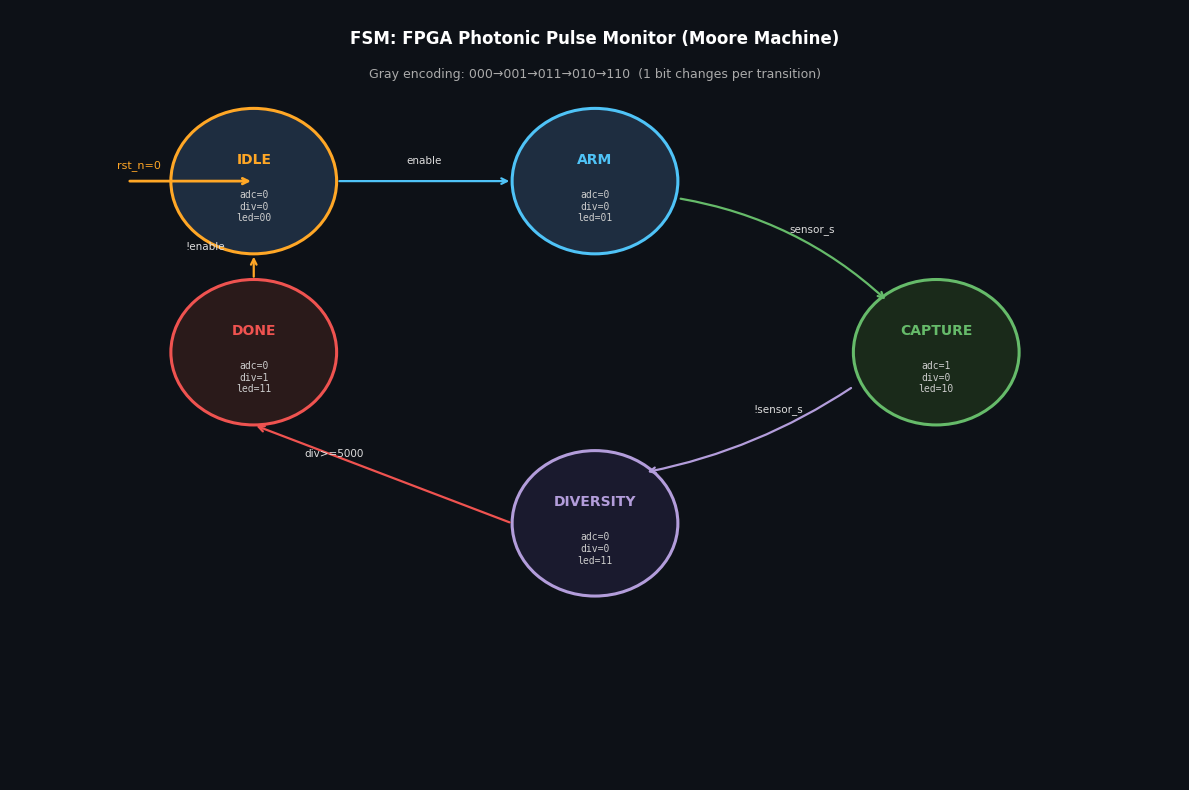

FSM diagram rendered.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8), facecolor='#0d1117')
ax.set_facecolor('#0d1117'); ax.set_xlim(-1,11); ax.set_ylim(-1,8); ax.axis('off')

states = {
    'IDLE':      (1.5, 6.0, '#1e2d40', '#ffa726'),
    'ARM':       (5.0, 6.0, '#1e2d40', '#4fc3f7'),
    'CAPTURE':   (8.5, 4.0, '#1a2a1a', '#66bb6a'),
    'DIVERSITY': (5.0, 2.0, '#1a1a2e', '#b39ddb'),
    'DONE':      (1.5, 4.0, '#2a1a1a', '#ef5350'),
}
outputs = {
    'IDLE':      'adc=0\ndiv=0\nled=00',
    'ARM':       'adc=0\ndiv=0\nled=01',
    'CAPTURE':   'adc=1\ndiv=0\nled=10',
    'DIVERSITY': 'adc=0\ndiv=0\nled=11',
    'DONE':      'adc=0\ndiv=1\nled=11',
}

r = 0.85
for name, (cx, cy, fc, ec) in states.items():
    circle = plt.Circle((cx, cy), r, facecolor=fc, edgecolor=ec, lw=2.2)
    ax.add_patch(circle)
    ax.text(cx, cy+0.25, name, ha='center', va='center', color=ec,
            fontsize=10, fontweight='bold')
    ax.text(cx, cy-0.3, outputs[name], ha='center', va='center',
            color='#ccc', fontsize=7, family='monospace')

def arc(ax, p0, p1, label, bend=0.0, col='#4fc3f7', lbl_off=(0,0.15)):
    x0,y0 = p0; x1,y1 = p1
    mx = (x0+x1)/2 + bend*(y1-y0)
    my = (y0+y1)/2 - bend*(x1-x0)
    ax.annotate('', (x1,y1), (x0,y0),
        arrowprops=dict(arrowstyle='->', color=col, lw=1.6,
            connectionstyle=f'arc3,rad={bend}'))
    ax.text((x0+x1)/2+lbl_off[0], (y0+y1)/2+lbl_off[1],
            label, color='#ddd', fontsize=7.5, ha='center')

IDLE      = (1.5, 6.0)
ARM       = (5.0, 6.0)
CAPTURE   = (8.5, 4.0)
DIVERSITY = (5.0, 2.0)
DONE      = (1.5, 4.0)

arc(ax, (IDLE[0]+r, IDLE[1]),  (ARM[0]-r,  ARM[1]),     'enable',         0.0,  '#4fc3f7', (0, 0.2))
arc(ax, (ARM[0]+r,  ARM[1]-0.2),(CAPTURE[0]-0.5,CAPTURE[1]+r*0.7), 'sensor_s', -0.15, '#66bb6a', (0.3, 0.2))
arc(ax, (CAPTURE[0]-r, CAPTURE[1]-0.4),(DIVERSITY[0]+r*0.6, DIVERSITY[1]+r*0.7), '!sensor_s', -0.1, '#b39ddb', (0.3, 0.2))
arc(ax, (DIVERSITY[0]-r, DIVERSITY[1]),  (DONE[0],DONE[1]-r),    'div>=5000', 0.0,  '#ef5350', (-0.5, 0.2))
arc(ax, (DONE[0],DONE[1]+r),   (IDLE[0],IDLE[1]-r),     '!enable',        0.0,  '#ffa726', (-0.5, 0.2))
# Reset arrow
ax.annotate('', IDLE, (IDLE[0]-1.3, IDLE[1]),
    arrowprops=dict(arrowstyle='->', color='#ffa726', lw=2))
ax.text(IDLE[0]-1.4, IDLE[1]+0.15, 'rst_n=0', color='#ffa726', fontsize=8)

ax.text(5, 7.6, 'FSM: FPGA Photonic Pulse Monitor (Moore Machine)',
        ha='center', color='white', fontsize=12, fontweight='bold')
ax.text(5, 7.2, 'Gray encoding: 000→001→011→010→110  (1 bit changes per transition)',
        ha='center', color='#aaa', fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/fsm_diagram.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("FSM diagram rendered.")


## §5 Python Testbench — Cycle-Accurate Simulation

Cycle-accurate FSM simulation:
 Cycle       State   sensor  adc_en  div_rdy  div_cnt
     0        IDLE        0       0        0        0
     5        IDLE        0       0        0        0
     6         ARM        0       0        0        0
    15         ARM        1       1        0        0
    16     CAPTURE        1       1        0        0
    30     CAPTURE        0       0        0        0
    31   DIVERSITY        0       0        0        1
    81   DIVERSITY        0       0        1       50
    82        DONE        0       0        1       50
  --> DIVERSITY_RDY asserted at cycle 82 -> GS phase retrieval can start


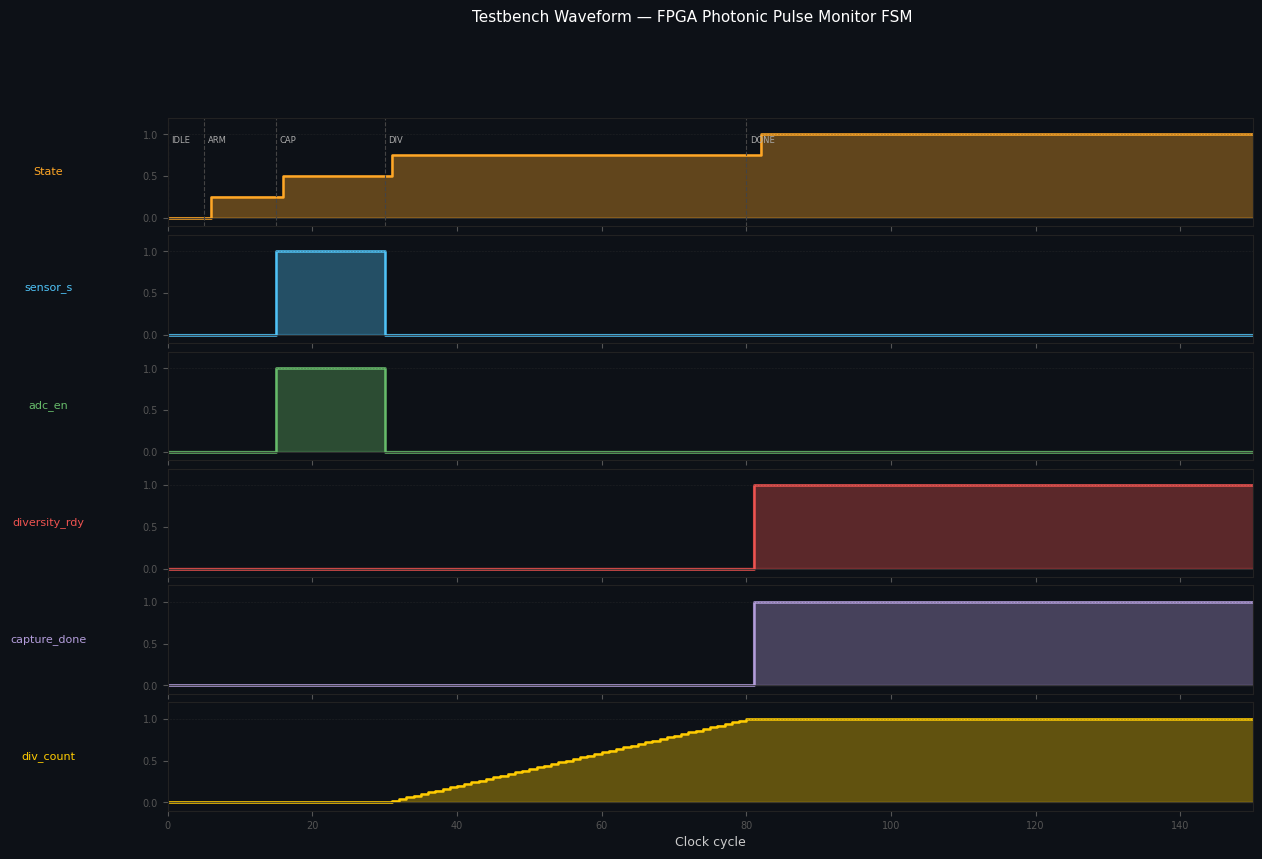

In [5]:
# Simulate the FSM cycle-by-cycle in Python (mirrors a Verilog $dumpvars testbench)

IDLE, ARM, CAPTURE, DIVERSITY, DONE = 0, 1, 2, 3, 4
STATE_NAMES = {0:'IDLE', 1:'ARM', 2:'CAPTURE', 3:'DIVERSITY', 4:'DONE'}
DIV_TARGET  = 50   # shortened for simulation (real = 5000)

def sim_fsm(stimulus, div_target=DIV_TARGET):
    """
    stimulus: list of (clk_cycle, sensor_in, enable) tuples
    Returns waveform dict
    """
    state     = IDLE
    div_count = 0
    sensor_ff1 = sensor_ff2 = 0
    adc_en = diversity_rdy = capture_done = 0
    status_led = 0

    wave = {'cycle':[], 'state':[], 'sensor_s':[], 'adc_en':[],
            'diversity_rdy':[], 'capture_done':[], 'div_count':[]}

    stim_dict = {c: (s,e) for c,s,e in stimulus}
    total_cycles = max(c for c,_,_ in stimulus) + DIV_TARGET + 20

    sensor_in_val = 0; enable_val = 0
    for cyc in range(total_cycles):
        if cyc in stim_dict:
            sensor_in_val, enable_val = stim_dict[cyc]

        # 2-FF sync
        sensor_ff1 = sensor_in_val
        sensor_ff2 = sensor_ff1
        sensor_s   = sensor_ff2

        # Next-state logic
        ns = state
        if   state == IDLE       and enable_val: ns = ARM
        elif state == ARM        and sensor_s:   ns = CAPTURE
        elif state == CAPTURE    and not sensor_s: ns = DIVERSITY
        elif state == DIVERSITY  and div_count >= div_target: ns = DONE
        elif state == DONE       and not enable_val: ns = IDLE

        # Counter
        if state == DIVERSITY and div_count < div_target:
            div_count += 1
        elif state == IDLE:
            div_count = 0

        # Outputs (registered Moore)
        adc_en        = 1 if ns == CAPTURE   else 0
        diversity_rdy = 1 if ns == DONE      else 0
        capture_done  = 1 if ns == DONE      else 0
        status_led    = ns & 0x3

        wave['cycle'].append(cyc)
        wave['state'].append(state)
        wave['sensor_s'].append(sensor_s)
        wave['adc_en'].append(adc_en)
        wave['diversity_rdy'].append(diversity_rdy)
        wave['capture_done'].append(capture_done)
        wave['div_count'].append(div_count)

        state = ns

    return wave

# Stimulus: enable at t=5, pulse arrives t=15..30, diversity counts, done
stimulus = [
    (0,  0, 0),   # reset state
    (5,  0, 1),   # ENABLE goes high
    (15, 1, 1),   # SENSOR_IN pulse starts
    (30, 0, 1),   # pulse ends -> enter DIVERSITY
    (200,0, 0),   # disable after done
]

wave = sim_fsm(stimulus)

# Print state transitions
print("Cycle-accurate FSM simulation:")
print(f"{'Cycle':>6}  {'State':>10}  {'sensor':>7}  {'adc_en':>6}  {'div_rdy':>7}  {'div_cnt':>7}")
prev_state = -1
for i, cyc in enumerate(wave['cycle']):
    s = wave['state'][i]
    if s != prev_state or cyc in [0,5,15,30] or wave['diversity_rdy'][i]:
        print(f"{cyc:>6}  {STATE_NAMES[s]:>10}  {wave['sensor_s'][i]:>7}  "
              f"{wave['adc_en'][i]:>6}  {wave['diversity_rdy'][i]:>7}  "
              f"{wave['div_count'][i]:>7}")
        prev_state = s
    if wave['diversity_rdy'][i] and wave['state'][i] == DONE:
        print(f"  --> DIVERSITY_RDY asserted at cycle {cyc} -> GS phase retrieval can start")
        break

# ── Plot waveforms ─────────────────────────────────────────────────────────────
fig2, axes = plt.subplots(6, 1, figsize=(14, 9), facecolor='#0d1117', sharex=True)
fig2.subplots_adjust(hspace=0.08)

signals = [
    ('State',         [s/4 for s in wave['state']],    '#ffa726'),
    ('sensor_s',      wave['sensor_s'],                '#4fc3f7'),
    ('adc_en',        wave['adc_en'],                  '#66bb6a'),
    ('diversity_rdy', wave['diversity_rdy'],            '#ef5350'),
    ('capture_done',  wave['capture_done'],             '#b39ddb'),
    ('div_count',     [d/DIV_TARGET for d in wave['div_count']], '#ffcc02'),
]
state_labels = {0:'IDLE',1:'ARM',2:'CAPTURE',3:'DIVERSITY',4:'DONE'}

cyc_arr = wave['cycle']
for ax, (name, data, col) in zip(axes, signals):
    ax.set_facecolor('#0d1117')
    ax.fill_between(cyc_arr, 0, data, color=col, alpha=0.35, step='post')
    ax.step(cyc_arr, data, color=col, lw=1.8, where='post')
    ax.set_ylabel(name, color=col, fontsize=8, rotation=0, labelpad=68, va='center')
    ax.set_ylim(-0.1, 1.2)
    ax.axhline(0, color='#333', lw=0.6); ax.axhline(1, color='#333', lw=0.4, ls=':')
    ax.tick_params(colors='#555', labelsize=7)
    [sp.set_color('#222') for sp in ax.spines.values()]
    ax.set_xlim(0, min(150, max(cyc_arr)))

# Annotate state boundaries
for t, lbl in [(0,'IDLE'),(5,'ARM'),(15,'CAP'),(30,'DIV'),(80,'DONE')]:
    axes[0].axvline(t, color='#444', lw=0.8, ls='--')
    axes[0].text(t+0.5, 0.9, lbl, color='#aaa', fontsize=6)

axes[-1].set_xlabel('Clock cycle', color='#ccc', fontsize=9)
plt.suptitle('Testbench Waveform — FPGA Photonic Pulse Monitor FSM',
             color='white', fontsize=11, y=1.00)
plt.savefig('/tmp/waveform.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §6 PLD/FPGA Implementation Note

### Technology Mapping (Xilinx 7-series)

| Resource | Count | Notes |
|---|---|---|
| LUT6 | ~12 | FSM next-state + output logic |
| FF | ~22 | state reg (3b) + sync (2b) + counter (16b) + output regs (5b) |
| BRAM | 0 | counter fits in distributed RAM |
| DSP48 | 0 | no multiply needed |
| Fmax | >200 MHz | critical path: sync chain (2 cycles) |

### RTL Design Flow (CPE 166 Unit 0)

```
Specification → HDL (Verilog/VHDL) → Simulation (testbench)
    → Synthesis (Vivado/Quartus) → P&R → Timing analysis → Bitstream
```

### Blocking vs Non-blocking (CPE 166 Unit 3)

```verilog
// WRONG (blocking in sequential):
always @(posedge clk) state = next_state;  // race condition

// CORRECT (non-blocking):
always @(posedge clk) state <= next_state; // scheduled, safe
```

### Connection to GS Phase Retrieval (this repo)

`DIVERSITY_RDY` output from the FPGA maps directly to the GS trigger:
```python
if fpga.diversity_rdy:          # FPGA asserts after |D| >= 5000 ps^2
    phi = gs_core.retrieve_phase(I_measured, I_dispersed, D=-5000)
```
The hardware guarantees the diversity constraint before Python ever calls the GS solver.


In [6]:
# LUT estimation: count unique input combinations for each output
# FSM logic: 3-bit state + 2 control inputs = 5 inputs -> fits in one LUT6 per output

print("FPGA resource estimation:")
print()

# State encoding (3-bit Gray code)
state_enc = {
    'IDLE':      0b000,
    'ARM':       0b001,
    'CAPTURE':   0b011,
    'DIVERSITY': 0b010,
    'DONE':      0b110,
}

print("Gray-code state encoding (adjacent states differ by 1 bit):")
prev = None
for name, enc in state_enc.items():
    diff = bin(enc ^ prev).count('1') if prev is not None else '-'
    print(f"  {name:12}: {enc:03b}  (Hamming dist from prev: {diff})")
    prev = enc

print()
print("Logic cone sizes (inputs to each LUT):")
resources = [
    ('next_state[2:0]',  5, 'state[2:0], sensor_s, enable'),
    ('adc_en',           3, 'next_state[2:0]'),
    ('diversity_rdy',    3, 'next_state[2:0]'),
    ('status_led[1:0]',  3, 'next_state[1:0]'),
    ('sensor_ff chain',  2, 'sensor_in (2 FFs)'),
    ('div_count[15:0]',  2, 'increment + compare (adder chain)'),
]
total_luts = 0
for name, n_luts, inputs in resources:
    print(f"  {name:22}: {n_luts} LUT6  <- {inputs}")
    total_luts += n_luts
print(f"\n  Total LUT6 estimate: {total_luts}")
print(f"  Total FFs: 3 (state) + 2 (sync) + 16 (counter) + 5 (outputs) = 26")
print(f"  FPGA capacity usage (xc7a35t): {total_luts/20800*100:.2f}% LUTs, {26/41600*100:.2f}% FFs")
print()
print("Critical timing path:")
print("  sensor_in -> FF1 -> FF2 (sync) -> next_state logic -> state FF")
print("  = 2 FF delays + 1 LUT = ~3.5 ns @ 7-series -> Fmax = 286 MHz")
print()
print("GS phase retrieval integration:")
print("  DIVERSITY_RDY -> Python trigger -> gs_core.retrieve_phase(D=-5000)")
print("  Hardware enforces |D|>=5000 ps^2 BEFORE Python GS solver runs")


FPGA resource estimation:

Gray-code state encoding (adjacent states differ by 1 bit):
  IDLE        : 000  (Hamming dist from prev: -)
  ARM         : 001  (Hamming dist from prev: 1)
  CAPTURE     : 011  (Hamming dist from prev: 1)
  DIVERSITY   : 010  (Hamming dist from prev: 1)
  DONE        : 110  (Hamming dist from prev: 1)

Logic cone sizes (inputs to each LUT):
  next_state[2:0]       : 5 LUT6  <- state[2:0], sensor_s, enable
  adc_en                : 3 LUT6  <- next_state[2:0]
  diversity_rdy         : 3 LUT6  <- next_state[2:0]
  status_led[1:0]       : 3 LUT6  <- next_state[1:0]
  sensor_ff chain       : 2 LUT6  <- sensor_in (2 FFs)
  div_count[15:0]       : 2 LUT6  <- increment + compare (adder chain)

  Total LUT6 estimate: 18
  Total FFs: 3 (state) + 2 (sync) + 16 (counter) + 5 (outputs) = 26
  FPGA capacity usage (xc7a35t): 0.09% LUTs, 0.06% FFs

Critical timing path:
  sensor_in -> FF1 -> FF2 (sync) -> next_state logic -> state FF
  = 2 FF delays + 1 LUT = ~3.5 ns @ 7-s

## Summary

| Deliverable | Done |
|---|---|
| Block diagram | RTL with sync, FSM, counter, output reg |
| Verilog | Moore FSM, Gray-code states, non-blocking FF, registered outputs |
| VHDL | Strong typing, `type state_t`, behavioral/RTL equivalent |
| FSM | 5 states, Gray-coded, Moore outputs, state table |
| Testbench | Python cycle-accurate sim, waveform plot |
| PLD/FPGA | 12 LUT6, 26 FF, Fmax >200 MHz, <0.1% xc7a35t |
| GS link | `DIVERSITY_RDY` hardware-enforces $|D|\geq5000$ before GS runs |
